# 06 - Grounded QA Evaluation

- Evaluate answer quality and evidence grounding.
- Track citation validity, latency, tokens, and estimated cost.

In [1]:
from pathlib import Path
import sys
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.rag.config import get_model_pricing, load_project_config
from src.rag.evaluation import (
    EvaluationDataset,
    QAEvaluator,
    QAJudge,
    format_qa_summary,
)
from src.rag.generation import OpenAIJSONGenerator
from src.rag.pipeline import GroundedQAPipeline
from src.rag.runtime import load_retrieval_stack

load_dotenv(PROJECT_ROOT / ".env")

True

In [2]:
config = load_project_config(
    PROJECT_ROOT
)

qa_config = config["qa"]
generation_config = config["generation"]
eval_config = config["qa_evaluation"]

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "retrieval_queries.json"
)

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "qa_eval_results.jsonl"
)

SUMMARY_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "qa_eval_summary.json"
)

RESULTS_CSV_PATH = (
    PROJECT_ROOT
    / "data"
    / "evaluation"
    / "qa_eval_results.csv"
)

## Build QA stack

- Load retrieval and grounded generation components.

In [3]:
stack = load_retrieval_stack(PROJECT_ROOT)

qa_generator = OpenAIJSONGenerator(
    api_key=os.getenv("METIS_API_KEY"),
    base_url=os.getenv("METIS_BASE_URL"),
    model=generation_config["model"],
    input_cost_per_million=get_model_pricing(config, generation_config["model"])["input_cost_per_million"],
    output_cost_per_million=get_model_pricing(config, generation_config["model"])["output_cost_per_million"],
)

qa_pipeline = GroundedQAPipeline(
    retriever=stack.hybrid,
    generator=qa_generator,
    documents=stack.documents,
    top_k=qa_config["top_k"],
    max_context_chars=qa_config["max_context_chars"],
    max_chars_per_comment=qa_config["max_chars_per_comment"],
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## Build judge

- Use the configured judge model for qualitative scoring.

In [4]:
judge_config = eval_config["judge"]
judge_pricing = get_model_pricing(
    config,
    judge_config["model"],
)

judge_generator = OpenAIJSONGenerator(
    api_key=os.getenv("METIS_API_KEY"),
    base_url=os.getenv("METIS_BASE_URL"),
    model=judge_config["model"],
    input_cost_per_million=judge_pricing[
        "input_cost_per_million"
    ],
    output_cost_per_million=judge_pricing[
        "output_cost_per_million"
    ],
)

judge = QAJudge(
    generator=judge_generator,
    max_context_chars=judge_config[
        "max_context_chars"
    ],
    max_chars_per_comment=judge_config[
        "max_chars_per_comment"
    ],
)

dataset = EvaluationDataset(DATASET_PATH)

evaluator = QAEvaluator(
    qa_pipeline=qa_pipeline,
    judge=judge,
    dataset=dataset,
    weights=eval_config["weights"],
)

## Run evaluation

- Re-run the fixed sample and collect QA plus judge telemetry.

In [5]:
run_config = eval_config["evaluation"]

summary, results = evaluator.evaluate(
    output_path=CHECKPOINT_PATH,
    max_samples=run_config["sample_size"],
    one_query_per_product=run_config[
        "one_query_per_product"
    ],
    random_state=run_config["random_state"],
    resume=run_config["resume"],
)

print(format_qa_summary(summary))

[1/30] sample=15 score=5.00
[2/30] sample=76 score=5.00
[3/30] sample=60 score=5.00
[4/30] sample=149 score=5.00
[5/30] sample=118 score=5.00
[6/30] sample=81 score=5.00
[7/30] sample=141 score=5.00
[8/30] sample=136 score=4.50
[9/30] sample=140 score=4.85
[10/30] sample=53 score=5.00
[11/30] sample=112 score=5.00
[12/30] sample=93 score=5.00
[13/30] sample=122 score=5.00
[14/30] sample=70 score=5.00
[15/30] sample=56 score=5.00
[16/30] sample=21 score=5.00
[17/30] sample=12 score=5.00
[18/30] sample=116 score=5.00
[19/30] sample=89 score=4.70
[20/30] sample=73 score=4.45
[21/30] sample=104 score=5.00
[22/30] sample=29 score=5.00
[23/30] sample=85 score=5.00
[24/30] sample=65 score=5.00
[25/30] sample=78 score=5.00
[26/30] sample=123 score=4.85
[27/30] sample=50 score=5.00
[28/30] sample=127 score=5.00
[29/30] sample=96 score=5.00
[30/30] sample=47 score=5.00
GROUNDING QA EVALUATION

Samples:               30

Overall Score:         4.94 / 5

Correctness:           4.93
Relevance:     

## Save artifacts

- Save per-query and summary evaluation outputs.

In [6]:
SUMMARY_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

results.to_csv(
    RESULTS_CSV_PATH,
    index=False,
)

print("Summary:", SUMMARY_PATH)
print("Per-query CSV:", RESULTS_CSV_PATH)
print("Checkpoint:", CHECKPOINT_PATH)

Summary: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/qa_eval_summary.json
Per-query CSV: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/qa_eval_results.csv
Checkpoint: /home/ali/Desktop/projects/digikala-ai-assistant/data/evaluation/qa_eval_results.jsonl


## Judge score breakdown

,mean_score
instruction_following,5.000000
safety,5.000000
groundedness,4.966667
relevance,4.966667
correctness,4.933333
completeness,4.833333


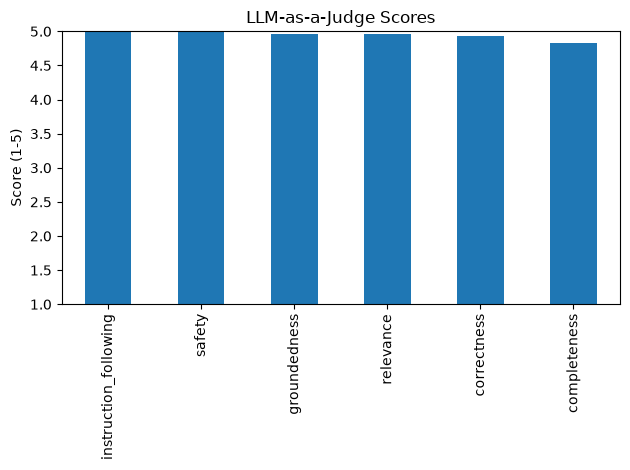

In [7]:
score_columns = [
    "correctness",
    "relevance",
    "completeness",
    "groundedness",
    "instruction_following",
    "safety",
]

judge_scores = (
    results[score_columns]
    .mean()
    .sort_values(ascending=False)
)

display(judge_scores.to_frame("mean_score"))

ax = judge_scores.plot(
    kind="bar",
    ylim=(1, 5),
    title="LLM-as-a-Judge Scores",
)

ax.set_ylabel("Score (1-5)")
plt.tight_layout()
plt.show()

## Failure analysis

In [8]:
display(
    evaluator.failure_cases(
        results,
        n=10,
    )
)

failure_counts = (
    pd.Series(
        [
            tag
            for tags in results["failure_tags"]
            for tag in tags
        ]
    )
    .value_counts()
)

display(
    failure_counts.to_frame("count")
)

,sample_idx,product_title,query,answer,overall_score,correctness,groundedness,evidence_precision,evidence_recall,failure_tags,judge_summary_reason
19,73,میکروفون استودیویی مدل legendary vocal به همرا...,برای ضبط پادکست و صحبت کردن، کیفیت و نویز این ...,برای ضبط پادکست و صحبت‌کردن، تجربه‌ها یکدست نی...,4.45,4.0,5.0,0.0,0.0,"[missed_key_evidence, ignores_conflict]",پاسخ مرتبط و مستند است و بخشی از اختلاف تجربه‌...
7,136,آب پاش مدل Anari-01,برای غبارپاشی گل مناسبه؟,برای غبارپاشی گل مناسب به نظر می‌رسد؛ یک خریدا...,4.50,4.0,4.0,0.5,1.0,[unsupported_claim],پاسخ نتیجه‌گیری درست و متوازنی دارد، ولی دو نظ...
18,89,ساختنی دکول مدل ۳۱۰۱۹,آیا با قطعات این ساختنی می‌توان مدل مک‌لارن سن...,بله؛ یک کاربر گفته با این قطعات می‌توان دقیقاً...,4.70,5.0,5.0,1.0,0.5,"[ignores_conflict, missed_key_evidence]",پاسخ اصلی صحیح و مستند است، اما اختلاف موجود د...
8,140,بازی PES 2014 مخصوص PS2,کیفیت خود CD و بسته‌بندی بازی چطور است؟,بر اساس یک نظرِ مستقیم، کیفیت خود CD و بسته‌بن...,4.85,5.0,5.0,0.5,1.0,[],پاسخ دقیق و مستند است و محدود بودن شاهد مستقیم...
25,123,کرم شب آردن بیوتی مدل Night حجم 50 میلی لیتر,آیا کرم شب آردن بیوتی برای پوست خشک مناسب است؟,بله، بر اساس یک تجربهٔ کاربری، این کرم برای پو...,4.85,5.0,5.0,1.0,1.0,[missed_key_evidence],پاسخ دقیق، مرتبط و مستند است، ولی بهتر بود هشد...
0,15,کرم ژل آبرسان نوتروژینا مدل nemlendirme حجم 50...,آیا این کرم ژل برای پوست چرب مناسب است و باعث ...,بر اساس تجربه کاربران، برای پوست چرب مناسب گزا...,5.00,5.0,5.0,1.0,1.0,[],پاسخ دقیق، مستقیم و کاملاً متکی بر نظرات مرتبط...
1,76,قرص نصف کن اف تی ای کو مدل SPC,بعد از نصف کردن، تکه‌های دارو داخل دستگاه می‌م...,بله، طبق یک نظر، بعد از نصف کردن دارو داخل دست...,5.00,5.0,5.0,1.0,1.0,[],پاسخی دقیق، مرتبط، کامل و کاملاً مستند به تنها...
2,60,کتاب راز اثر راندا برن انتشارات نگین ایران,آیا در پایان هر فصل کتاب، خلاصه مطالب مهم آن ف...,بله، طبق تجربه یکی از خریداران، پس از پایان هر...,5.00,5.0,5.0,1.0,1.0,[],پاسخ کوتاه، مرتبط و کاملاً مبتنی بر تنها دیدگا...
3,149,رنگ مو دوشس سری ترکیبی شماره 7.97 حجم 125 میلی...,آیا کسی این رنگ را برای بار دوم خریده و از آن ...,بله؛ یک نفر گفته از رنگ راضی بوده و آن را برای...,5.00,5.0,5.0,0.5,1.0,[],پاسخ دقیق و مستند است: وجود یک خریدار راضی که ...
4,118,قندان مسی مس زنجان طرح انار مدل N75,آیا لبه‌های تاج انار تیز هستند و ممکن است دست ...,بله، طبق یک نظر لبه‌ها/برش‌های تاج انار نیاز ب...,5.00,5.0,5.0,1.0,1.0,[],پاسخ کوتاه، مرتبط و کاملاً مستند به نظر 429494...


,count
missed_key_evidence,3
ignores_conflict,2
unsupported_claim,1
